<a href="https://www.kaggle.com/code/sonawanelalitsunil/used-cars-sales-listings-2025-ml-70-77?scriptVersionId=256548398" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/used-car-sales-listings-dataset-2025/used_car_listings.json
/kaggle/input/used-car-sales-listings-dataset-2025/used_car_listings.csv
/kaggle/input/used-car-sales-listings-dataset-2025/used_car_listings.sqlite
/kaggle/input/used-car-sales-listings-dataset-2025/used_car_listings.xlsx


## Title:
Used Cars Sales Listings 2025

## Description:
This dataset contains detailed information on used car sales for 2025, including attributes such as make, model, year, mileage, engine type, transmission, fuel type, location, listing price, and seller details. It is designed for analyzing market trends, price prediction, and buyer behavior patterns in the used car industry. The dataset can be used for machine learning projects, such as predicting car prices, identifying popular car models, and understanding regional sales trends.

## Import dataset

In [2]:
df = pd.read_csv("/kaggle/input/used-car-sales-listings-dataset-2025/used_car_listings.csv")

In [3]:
df.head()

,listing_id,vin,make,model,year,trim,body_type,fuel_type,transmission,mileage,price,condition,location,seller_type,features
0,1,9M6LF68V634LY2252,Tesla,Model 3,2019,NaN,Coupe,Electric,Manual,46134,19919.0,good,"New Lindsey, GA, US",Dealer,"Alloy Wheels, Android Auto, Apple CarPlay, Fog..."
1,2,1S0ZCY536BSCY2864,Nissan,Rogue,2024,LT,Sedan,Hybrid,Automatic,16109,19480.0,good,"Pughtown, CO, US",Dealer,"Alloy Wheels, Android Auto, Lane Keep Assist, ..."
2,3,YFB625BN0RTMZ5590,Hyundai,i20,2018,XLE,Crossover,Petrol,Automatic,173239,4556.0,good,"Satna, HR, India",Dealer,"Alloy Wheels, Bluetooth, Panoramic Roof, Sunroof"
3,4,CPMZ4RFN5WYL37096,Kia,Sportage,2023,EX,Hatchback,Diesel,CVT,36810,11536.0,fair,"山武市, Osaka, Japan",Certified Pre-Owned,"Alloy Wheels, Bluetooth, Keyless Entry, Naviga..."
4,5,4PJZG3MV6D9365673,Kia,Seltos,2020,Trend,Pickup,Diesel,Automatic,87749,14098.0,good,"長生郡長生村, Osaka, Japan",Certified Pre-Owned,"Apple CarPlay, Backup Camera, Bluetooth, Heate..."


In [4]:
df.tail()

,listing_id,vin,make,model,year,trim,body_type,fuel_type,transmission,mileage,price,condition,location,seller_type,features
2063,2064,06B83BVF8F2W81547,Skoda,Kushaq,2023,Sport,Pickup,Petrol,Automatic,24566,34696.0,like new,"Shahjahanpur, KA, India",Certified Pre-Owned,"Blind Spot Monitor, Keyless Entry, Panoramic R..."
2064,2065,4P7083L79MBVK5696,Mahindra,Scorpio,2016,XSE,SUV,Diesel,Automatic,122459,2642.0,excellent,"Marques, PR, Brazil",Dealer,"Adaptive Cruise Control, Backup Camera, LED He..."
2065,2066,5RERFW1M7B00A4061,Audi,A6,2018,EX,Hatchback,Diesel,DCT,120452,7093.0,good,"Dhanbad, KL, India",Private Party,"Adaptive Cruise Control, Android Auto, Blind S..."
2066,2067,DJB6DBAS5UNNX0757,Skoda,Kushaq,2021,LX,MPV,Petrol,Manual,57043,11296.0,excellent,"Caitlinstad, NL, Canada",Certified Pre-Owned,"Backup Camera, Panoramic Roof, Parking Sensors..."
2067,2068,8BUANECR64R9L0827,Chevrolet,Malibu,2024,Platinum,Sedan,Diesel,Automatic,20218,23558.0,excellent,"Stadtroda, HH, Germany",Certified Pre-Owned,"Adaptive Cruise Control, Android Auto, Apple C..."


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2068 entries, 0 to 2067
Data columns (total 15 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   listing_id    2068 non-null   int64  
 1   vin           2068 non-null   object 
 2   make          2068 non-null   object 
 3   model         2068 non-null   object 
 4   year          2068 non-null   int64  
 5   trim          1824 non-null   object 
 6   body_type     2068 non-null   object 
 7   fuel_type     2068 non-null   object 
 8   transmission  2068 non-null   object 
 9   mileage       2068 non-null   int64  
 10  price         2068 non-null   float64
 11  condition     2022 non-null   object 
 12  location      2068 non-null   object 
 13  seller_type   2068 non-null   object 
 14  features      1917 non-null   object 
dtypes: float64(1), int64(3), object(11)
memory usage: 242.5+ KB


In [6]:
df.describe()

,listing_id,year,mileage,price
count,2068.000000,2068.000000,2068.000000,2068.000000
mean,1034.500000,2016.975822,115626.364603,9182.621857
std,597.124498,4.610981,80971.112603,9964.093618
min,1.000000,2005.000000,0.000000,1140.000000
25%,517.750000,2014.000000,57683.250000,2323.750000
50%,1034.500000,2017.000000,99212.000000,5448.500000
75%,1551.250000,2020.000000,159291.500000,11946.750000
max,2068.000000,2025.000000,418428.000000,72641.000000


In [7]:
df.dtypes

listing_id        int64
vin              object
make             object
model            object
year              int64
trim             object
body_type        object
fuel_type        object
transmission     object
mileage           int64
price           float64
condition        object
location         object
seller_type      object
features         object
dtype: object

In [8]:
df.shape

(2068, 15)

In [9]:
df.isnull().sum()

listing_id        0
vin               0
make              0
model             0
year              0
trim            244
body_type         0
fuel_type         0
transmission      0
mileage           0
price             0
condition        46
location          0
seller_type       0
features        151
dtype: int64

In [10]:
df.duplicated().sum()

0

In [11]:
df.columns

Index(['listing_id', 'vin', 'make', 'model', 'year', 'trim', 'body_type',
       'fuel_type', 'transmission', 'mileage', 'price', 'condition',
       'location', 'seller_type', 'features'],
      dtype='object')

## Data visualizations

In [12]:
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
palette = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd"]

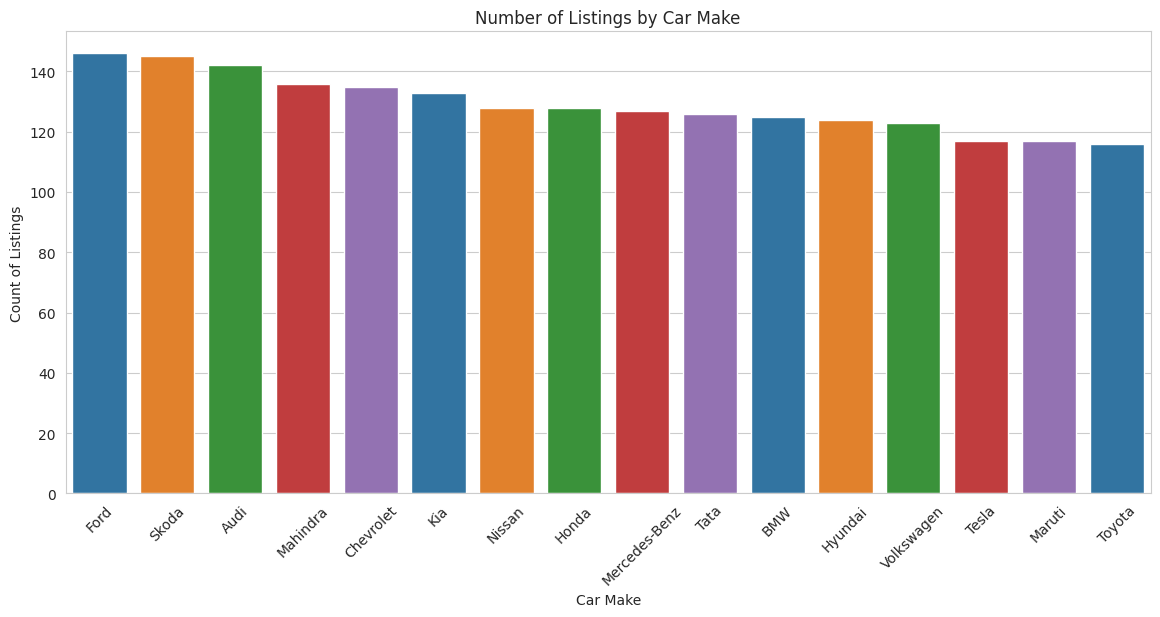

In [13]:
plt.figure(figsize=(14,6))
sns.countplot(data=df, x='make', order=df['make'].value_counts().index, palette=palette)
plt.title('Number of Listings by Car Make')
plt.xticks(rotation=45)
plt.ylabel('Count of Listings')
plt.xlabel('Car Make')
plt.show()

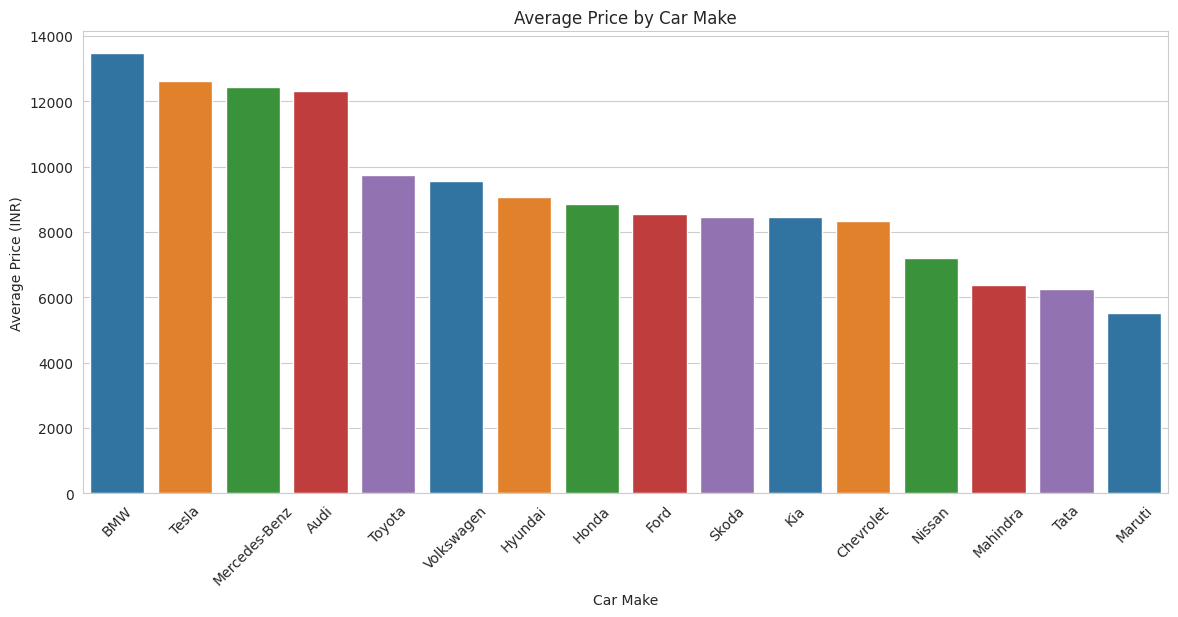

In [14]:
avg_price_make = df.groupby('make')['price'].mean().sort_values(ascending=False)
plt.figure(figsize=(14,6))
sns.barplot(x=avg_price_make.index, y=avg_price_make.values, palette=palette)
plt.title('Average Price by Car Make')
plt.xticks(rotation=45)
plt.ylabel('Average Price (INR)')
plt.xlabel('Car Make')
plt.show()

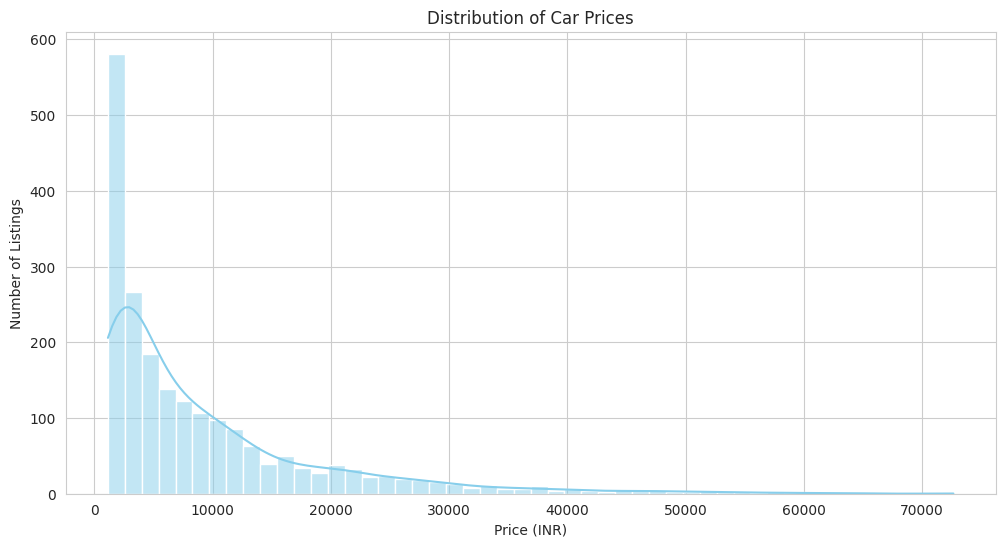

In [15]:
plt.figure(figsize=(12,6))
sns.histplot(df['price'], bins=50, kde=True, color='skyblue')
plt.title('Distribution of Car Prices')
plt.xlabel('Price (INR)')
plt.ylabel('Number of Listings')
plt.show()

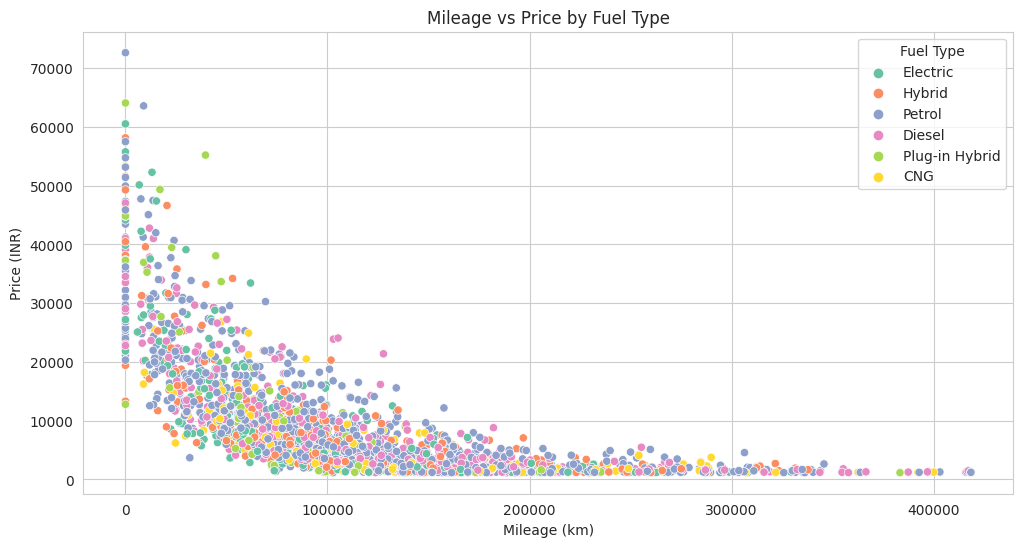

In [16]:
plt.figure(figsize=(12,6))
sns.scatterplot(data=df, x='mileage', y='price', hue='fuel_type', palette='Set2')
plt.title('Mileage vs Price by Fuel Type')
plt.xlabel('Mileage (km)')
plt.ylabel('Price (INR)')
plt.legend(title='Fuel Type')
plt.show()

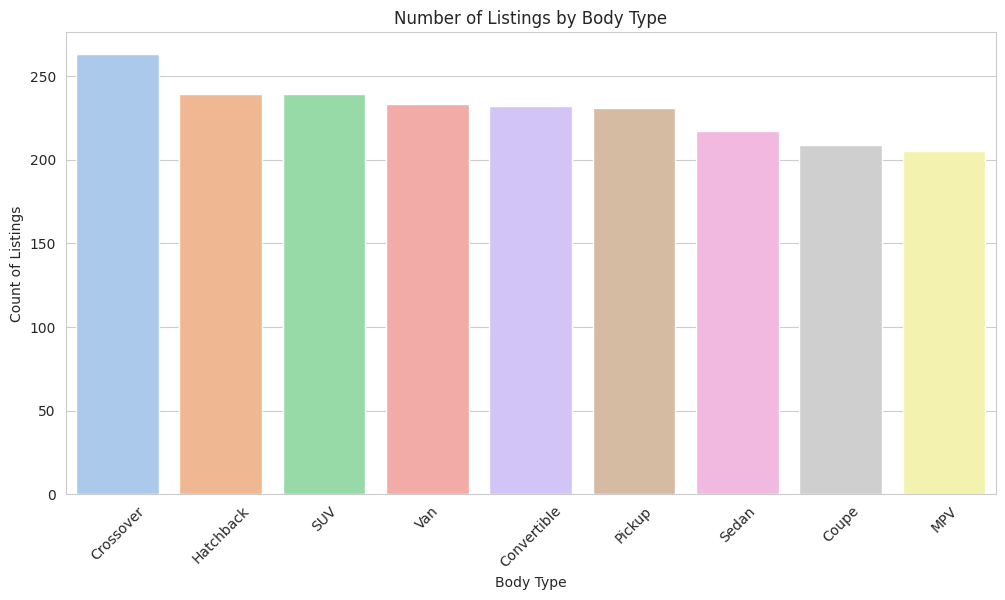

In [17]:
plt.figure(figsize=(12,6))
sns.countplot(data=df, x='body_type', order=df['body_type'].value_counts().index, palette='pastel')
plt.title('Number of Listings by Body Type')
plt.xticks(rotation=45)
plt.ylabel('Count of Listings')
plt.xlabel('Body Type')
plt.show()

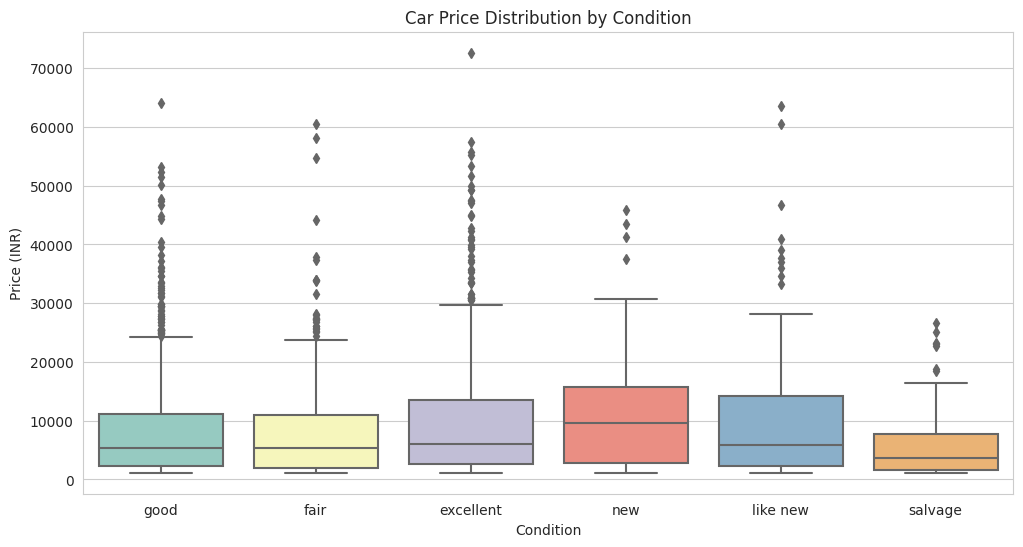

In [18]:
plt.figure(figsize=(12,6))
sns.boxplot(data=df, x='condition', y='price', palette='Set3')
plt.title('Car Price Distribution by Condition')
plt.ylabel('Price (INR)')
plt.xlabel('Condition')
plt.show()

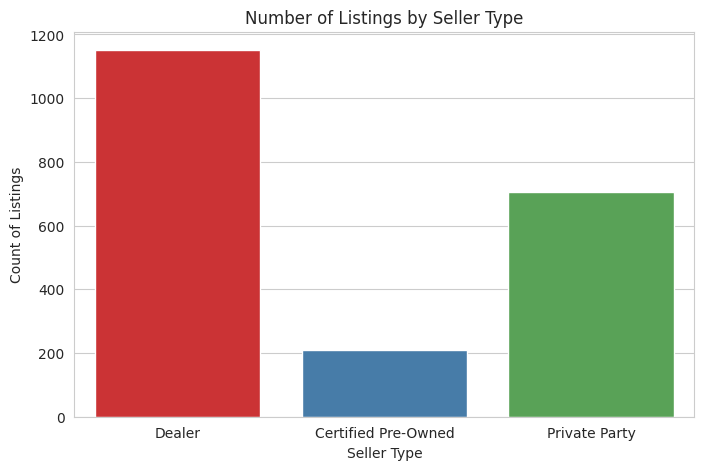

In [19]:
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='seller_type', palette='Set1')
plt.title('Number of Listings by Seller Type')
plt.xlabel('Seller Type')
plt.ylabel('Count of Listings')
plt.show()


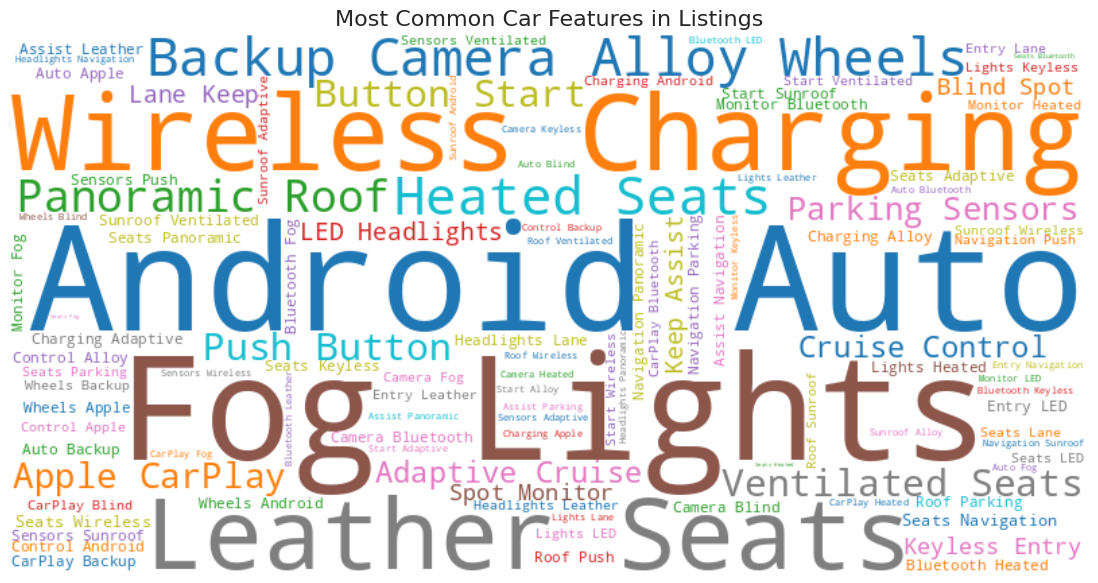

In [20]:
from wordcloud import WordCloud

all_features = ' '.join(df['features'].dropna().astype(str))
wordcloud = WordCloud(width=800, height=400, background_color='white', colormap='tab10').generate(all_features)

plt.figure(figsize=(15,7))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Most Common Car Features in Listings', fontsize=16)
plt.show()

## Predictive modeling

In [21]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score

# ML Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

In [22]:
num_cols = ['year', 'mileage', 'price']
num_imputer = SimpleImputer(strategy='median')
df[num_cols] = num_imputer.fit_transform(df[num_cols])

# Fill missing categorical values
cat_cols = ['make','model','trim','body_type','fuel_type','transmission','condition','location','seller_type']
cat_imputer = SimpleImputer(strategy='most_frequent')
df[cat_cols] = cat_imputer.fit_transform(df[cat_cols])

In [23]:
le = LabelEncoder()
for col in cat_cols:
    df[col] = le.fit_transform(df[col])

# Define features and target
X = df[['make','model','year','trim','body_type','fuel_type','transmission','mileage','condition','location','seller_type']]
y = df['price']

In [24]:
y = pd.qcut(y, q=4, labels=False) 

In [25]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [26]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "Naive Bayes": GaussianNB(),
    "SVM": SVC(),
    "KNN": KNeighborsClassifier()
}

In [27]:
accuracy_results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred) * 100
    accuracy_results[name] = round(acc, 2)

In [28]:
print("Model Accuracies (%):")
for model_name, acc in accuracy_results.items():
    print(f"{model_name}: {acc}%")


Model Accuracies (%):
Logistic Regression: 54.59%
Decision Tree: 64.98%
Random Forest: 72.95%
Naive Bayes: 62.56%
SVM: 57.0%
KNN: 49.76%


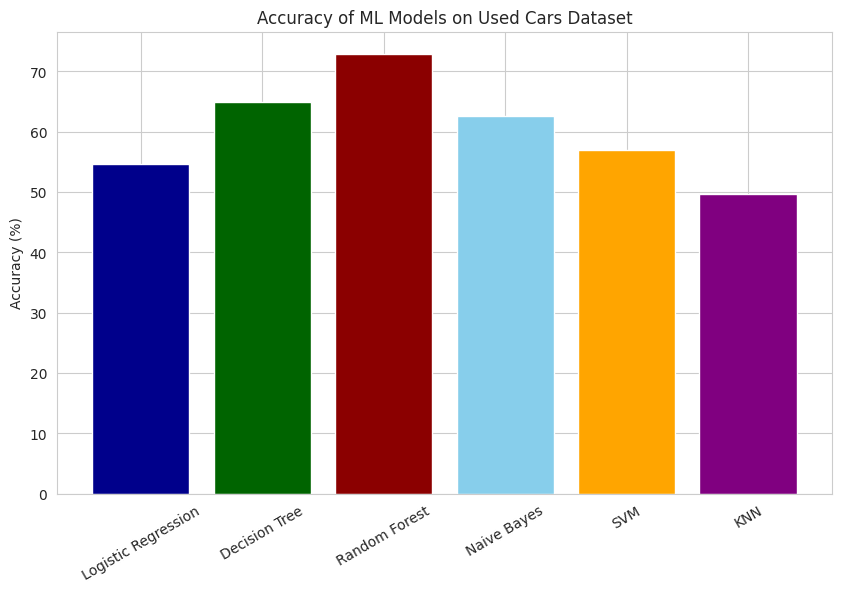

In [29]:
plt.figure(figsize=(10,6))
plt.bar(accuracy_results.keys(), accuracy_results.values(), color=['darkblue','darkgreen','darkred','skyblue','orange','purple'])
plt.title('Accuracy of ML Models on Used Cars Dataset')
plt.ylabel('Accuracy (%)')
plt.xticks(rotation=30)
plt.show()

## Thank you..pls upvote!!!